# Data, EDA, Feature Engineering & Metric Definition

**Dataset:** Kaggle Playground Series S6E5 — F1 Pit-Stop Prediction  
**Target:** `PitNextLap` (binary - will the driver pit on the next lap?)

This notebook covers PPT requirements **#1 (EDA)** and **#2 (Metric)** and produces a feature-engineered dataset for training pipeline.

**Sections**
1. Load data
2. Quick inspection
3. Train/Test split by `Year`
4. EDA — class distribution
5. EDA — Compound analysis
6. EDA — TyreLife vs PitNextLap
7. EDA — Year-over-year drift (very important finding)
8. Correlation analysis
9. Feature engineering
10. Metric definition + baselines
11. Save artifacts
12. Summary

## 0. Setup

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110
sns.set_style('whitegrid')

# ---- EDIT THESE TWO PATHS ----
TRAIN_CSV = '../data/train.csv'   # raw train.csv
OUT_DIR   = './EDA_output'

os.makedirs(os.path.join(OUT_DIR, 'data'), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, 'figures'), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, 'reports'), exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: ./EDA_output


## 1. Load data

In [2]:
df = pd.read_csv(TRAIN_CSV)
print('Shape:', df.shape)
df.head()

Shape: (439140, 16)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 2. Quick inspection

In [3]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== missing values ===')
print(df.isna().sum())
print('\n=== Year distribution ===')
print(df['Year'].value_counts().sort_index())
print('\n=== Target (PitNextLap) distribution ===')
print(df['PitNextLap'].value_counts())
print('Overall positive rate:', df['PitNextLap'].mean().round(4))

=== dtypes ===
id                          int64
Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

=== missing values ===
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Ch

In [4]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


**Observations**
- 439,140 rows, **no missing values** in any column.
- Target `PitNextLap` is binary, with positive rate ≈ 20 %.
- 16 columns: 4 categorical/ID, 11 numeric features, 1 target.

## 3. Train/Test split by Year

Per the project brief: **2022–2024 = train, 2025 = test**.

In [5]:
train = df[df['Year'].isin([2022, 2023, 2024])].reset_index(drop=True)
test  = df[df['Year'] == 2025].reset_index(drop=True)

print(f'Train (2022-2024): {train.shape}  positive_rate = {train["PitNextLap"].mean():.4f}')
print(f'Test  (2025):      {test.shape}   positive_rate = {test["PitNextLap"].mean():.4f}')
print('\nTrain year breakdown:')
print(train['Year'].value_counts().sort_index())

Train (2022-2024): (346246, 16)  positive_rate = 0.1761
Test  (2025):      (92894, 16)   positive_rate = 0.2844

Train year breakdown:
Year
2022     82989
2023    136147
2024    127110
Name: count, dtype: int64


## 4. EDA — Class distribution

Plot the class balance for train and test.

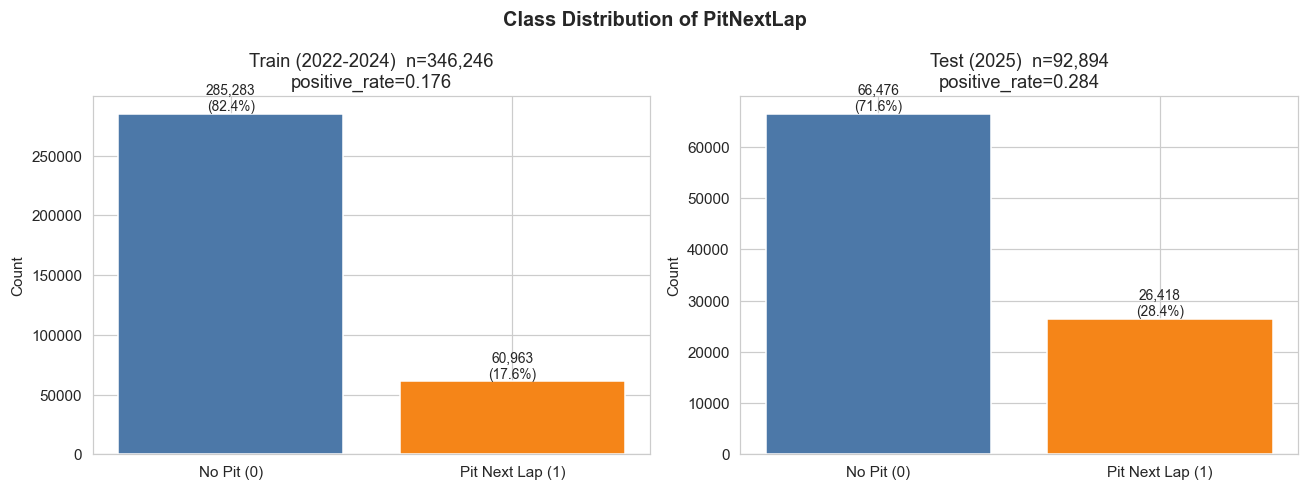

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, sub, title in [(axes[0], train, f'Train (2022-2024)  n={len(train):,}'),
                       (axes[1], test,  f'Test (2025)  n={len(test):,}')]:
    c = sub['PitNextLap'].value_counts().sort_index()
    bars = ax.bar(['No Pit (0)', 'Pit Next Lap (1)'], c.values, color=['#4C78A8', '#F58518'])
    ax.set_title(f'{title}\npositive_rate={sub["PitNextLap"].mean():.3f}')
    ax.set_ylabel('Count')
    for b, v in zip(bars, c.values):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}\n({v/len(sub):.1%})',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Class Distribution of PitNextLap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figures/01_class_distribution.png'), bbox_inches='tight')
plt.show()

**Finding:** roughly **4 : 1** imbalance in favour of *no pit*. The 2025 test slice is more pit-heavy (28.4 %) than the training period (17.6 %) — see §7 for why.

This imbalance is the central reason we will **not** use Accuracy as the primary metric (§10).

## 5. EDA — Compound analysis

In [7]:
comp_counts = train['Compound'].value_counts()
comp_rate   = train.groupby('Compound')['PitNextLap'].mean().sort_values(ascending=False)
comp_table  = pd.DataFrame({'count': comp_counts, 'share': comp_counts/len(train), 'pit_rate': comp_rate})
comp_table.round(3)

,count,share,pit_rate
Compound,,,
HARD,136484,0.394,0.289
INTERMEDIATE,14016,0.040,0.164
MEDIUM,163358,0.472,0.086
SOFT,31035,0.090,0.165
WET,1353,0.004,0.025


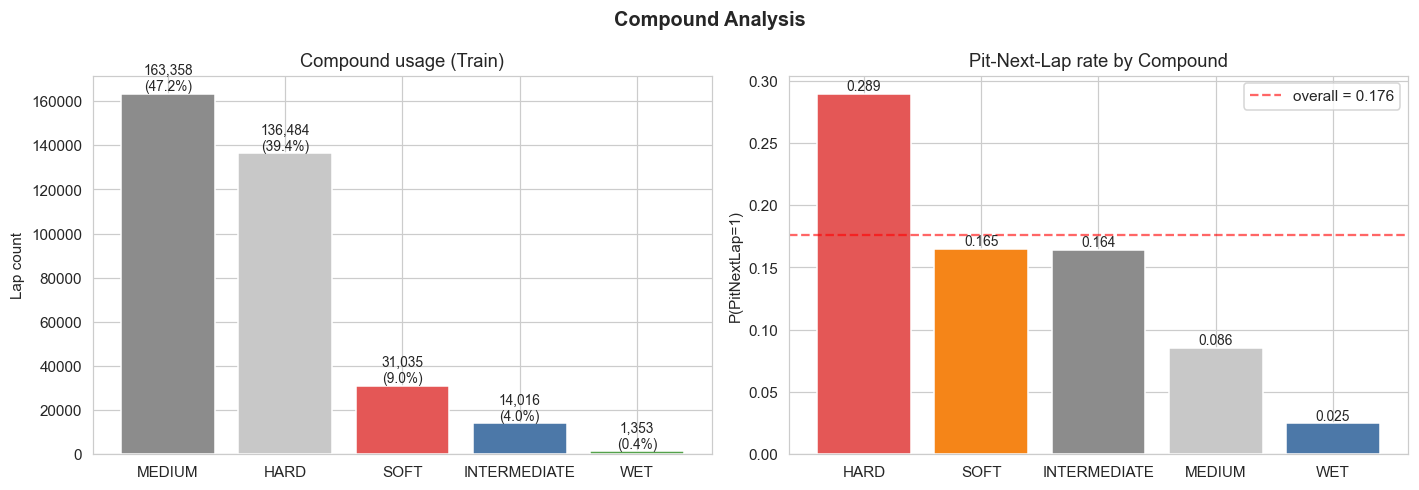

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(comp_counts.index, comp_counts.values,
            color=['#8C8C8C', '#C8C8C8', '#E45756', '#4C78A8', '#54A24B'])
axes[0].set_title('Compound usage (Train)')
axes[0].set_ylabel('Lap count')
for i, v in enumerate(comp_counts.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(train):.1%})', ha='center', va='bottom', fontsize=9)

axes[1].bar(comp_rate.index, comp_rate.values,
            color=['#E45756', '#F58518', '#8C8C8C', '#C8C8C8', '#4C78A8'])
axes[1].axhline(train['PitNextLap'].mean(), color='red', linestyle='--', alpha=0.6,
                label=f'overall = {train["PitNextLap"].mean():.3f}')
axes[1].set_title('Pit-Next-Lap rate by Compound')
axes[1].set_ylabel('P(PitNextLap=1)')
axes[1].legend()
for i, v in enumerate(comp_rate.values):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Compound Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figures/02_compound_analysis.png'), bbox_inches='tight')
plt.show()

**Findings**
- **HARD** (39 % of laps) has the highest pit-next-lap rate (**0.29**, ≈ 3× the baseline). Hard compounds run long stints — when we see them, the driver is often deep into a stint.
- **MEDIUM** (47 %) is the lowest (**0.09**) — primary tyre, mostly mid-life laps.
- **WET** (0.4 %) is rare and time-bounded; almost never pits next lap.
- *Compound* is a strong categorical predictor.

## 6. EDA — TyreLife vs PitNextLap

TyreLife = number of laps already done on the current tyre. Intuitively the older the tyre the more likely to pit.

In [9]:
tmp = train.copy()
tmp['_tl_bucket'] = pd.cut(tmp['TyreLife'],
    bins=[-0.1, 5, 10, 15, 20, 25, 30, 40, 60, 200],
    labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-40','41-60','60+'])
pit_by_tl = tmp.groupby('_tl_bucket', observed=True)['PitNextLap'].agg(['mean','count'])
pit_by_tl.round(3)

,mean,count
_tl_bucket,,
0-5,0.049,70883
6-10,0.121,74310
11-15,0.177,69525
16-20,0.237,52532
21-25,0.270,34822
26-30,0.294,21742
31-40,0.335,17136
41-60,0.414,4879
60+,0.729,417


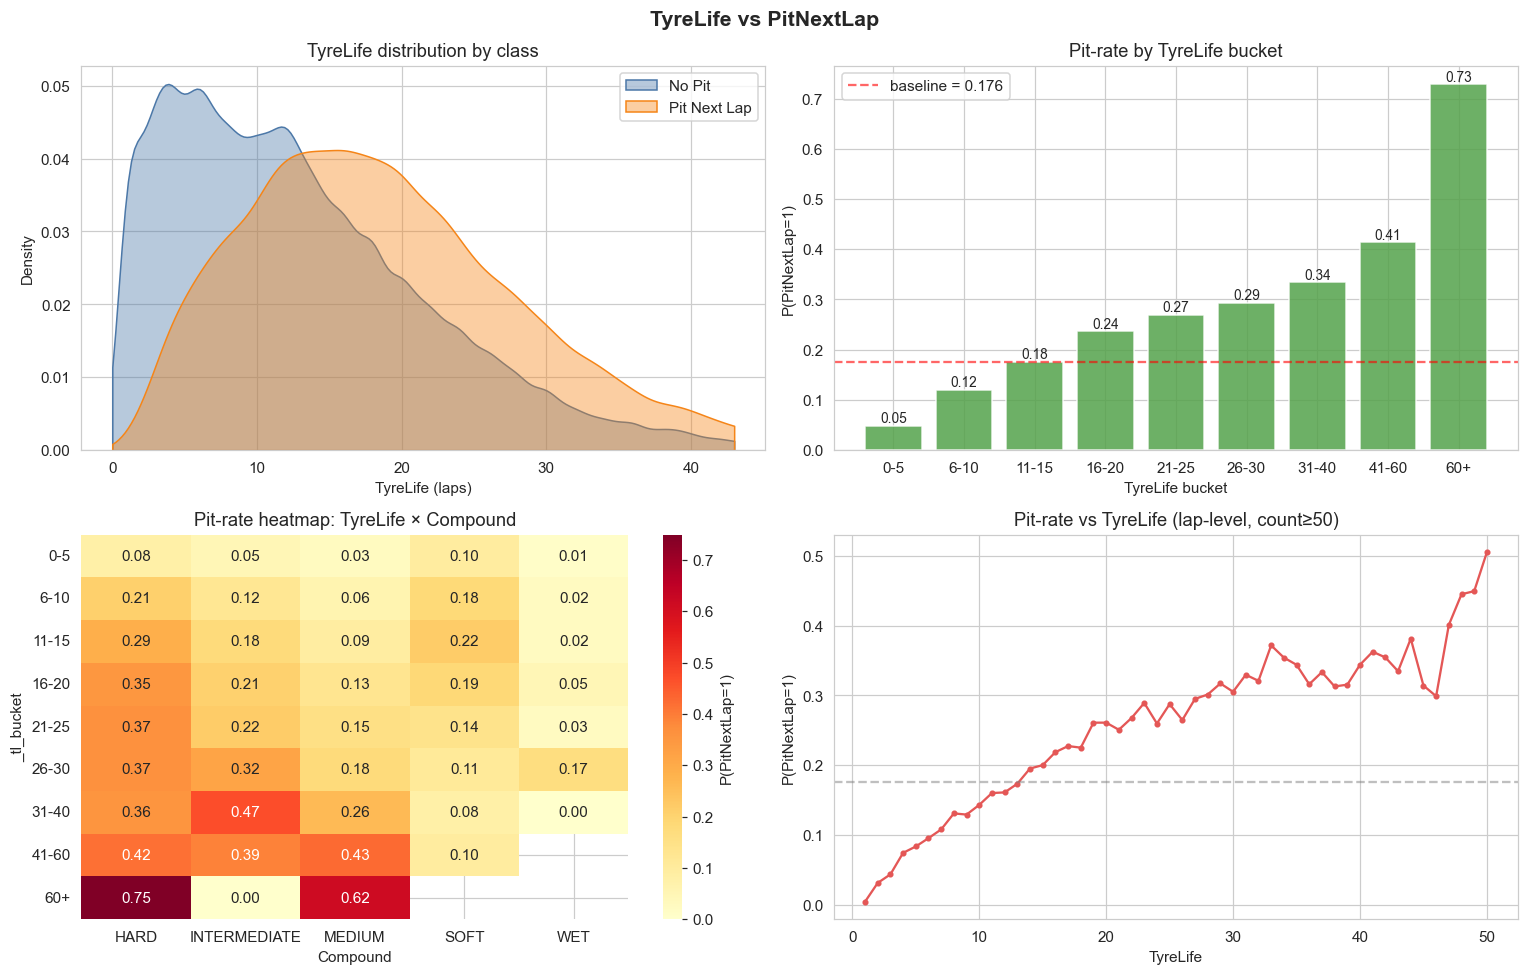

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 6a. KDE of TyreLife by class
for cls, color, lbl in [(0, '#4C78A8', 'No Pit'), (1, '#F58518', 'Pit Next Lap')]:
    sns.kdeplot(tmp.loc[tmp['PitNextLap']==cls, 'TyreLife'], ax=axes[0,0],
                color=color, fill=True, alpha=0.4, label=lbl,
                clip=(0, tmp['TyreLife'].quantile(0.99)))
axes[0,0].set_title('TyreLife distribution by class')
axes[0,0].set_xlabel('TyreLife (laps)')
axes[0,0].legend()

# 6b. Pit-rate by TyreLife bucket
axes[0,1].bar(pit_by_tl.index.astype(str), pit_by_tl['mean'], color='#54A24B', alpha=0.85)
axes[0,1].axhline(train['PitNextLap'].mean(), color='red', linestyle='--', alpha=0.6,
                  label=f'baseline = {train["PitNextLap"].mean():.3f}')
axes[0,1].set_title('Pit-rate by TyreLife bucket')
axes[0,1].set_xlabel('TyreLife bucket')
axes[0,1].set_ylabel('P(PitNextLap=1)')
axes[0,1].legend()
for i, v in enumerate(pit_by_tl['mean'].values):
    axes[0,1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# 6c. heatmap: TyreLife bucket × Compound
pivot = tmp.pivot_table(values='PitNextLap', index='_tl_bucket', columns='Compound',
                        aggfunc='mean', observed=True)
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1,0],
            cbar_kws={'label': 'P(PitNextLap=1)'})
axes[1,0].set_title('Pit-rate heatmap: TyreLife × Compound')

# 6d. lap-by-lap pit-probability curve
agg = tmp.groupby('TyreLife')['PitNextLap'].agg(['mean','count']).reset_index()
agg = agg[(agg['count'] >= 50) & (agg['TyreLife'] <= 50)]
axes[1,1].plot(agg['TyreLife'], agg['mean'], marker='o', markersize=3, color='#E45756')
axes[1,1].set_title('Pit-rate vs TyreLife (lap-level, count≥50)')
axes[1,1].set_xlabel('TyreLife')
axes[1,1].set_ylabel('P(PitNextLap=1)')
axes[1,1].axhline(train['PitNextLap'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.suptitle('TyreLife vs PitNextLap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figures/03_tyrelife_vs_pitnextlap.png'), bbox_inches='tight')
plt.show()

**Findings**
- Pit-rate increases **monotonically** with TyreLife: 0–5 laps (5 %) → 60+ laps (73 %).
- The heatmap shows HARD tyres at 30+ laps reach ~50 % pit probability — a useful interaction term for tree models.
- TyreLife is the single strongest numeric predictor (correlation analysis in §8).

## 7. EDA — Year-over-year drift (**important finding**)

In [11]:
year_rate = df.groupby('Year')['PitNextLap'].agg(['mean','count']).round(4)
year_rate

,mean,count
Year,,
2022,0.2665,82989
2023,0.0096,136147
2024,0.2953,127110
2025,0.2844,92894


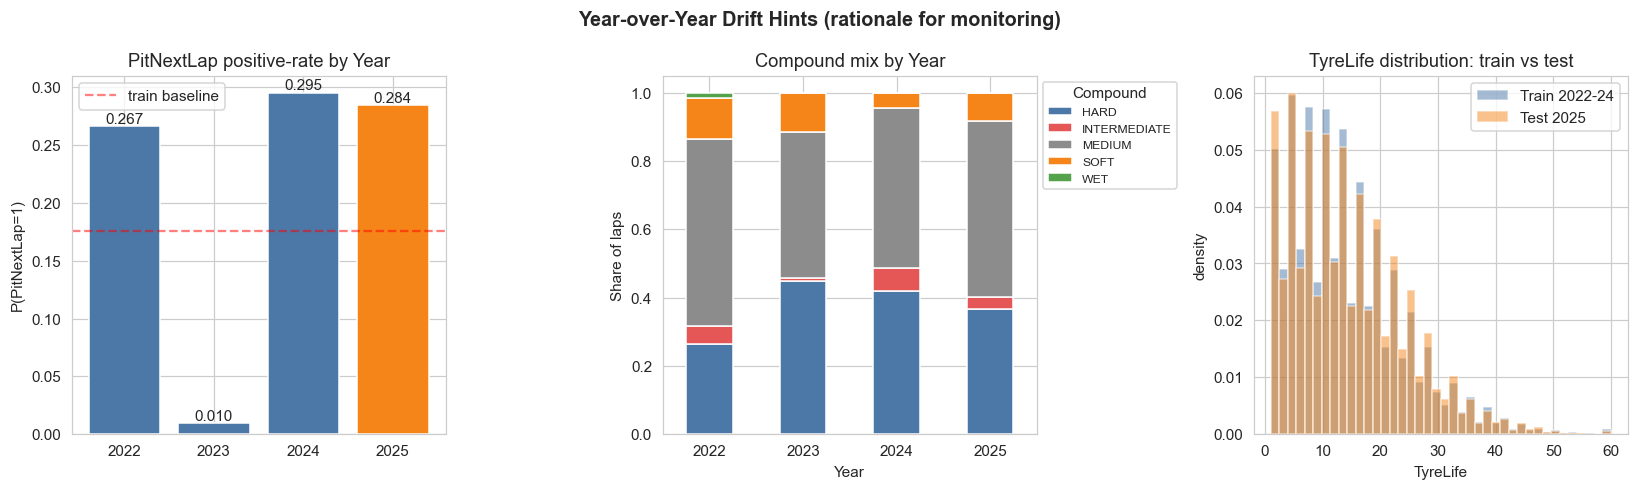

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 7a. positive rate per year
yr = df.groupby('Year')['PitNextLap'].mean()
axes[0].bar(yr.index.astype(str), yr.values, color=['#4C78A8']*3 + ['#F58518'])
axes[0].set_title('PitNextLap positive-rate by Year')
axes[0].set_ylabel('P(PitNextLap=1)')
for i, v in enumerate(yr.values):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')
axes[0].axhline(train['PitNextLap'].mean(), color='red', linestyle='--', alpha=0.5, label='train baseline')
axes[0].legend()

# 7b. compound mix per year
cy = df.groupby(['Year','Compound']).size().unstack(fill_value=0)
cy_pct = cy.div(cy.sum(axis=1), axis=0)
cy_pct.plot(kind='bar', stacked=True, ax=axes[1],
            color=['#4C78A8','#E45756','#8C8C8C','#F58518','#54A24B'])
axes[1].set_title('Compound mix by Year')
axes[1].set_ylabel('Share of laps')
axes[1].legend(title='Compound', bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=8)
axes[1].set_xticklabels(cy_pct.index, rotation=0)

# 7c. TyreLife distribution train vs test
axes[2].hist(train['TyreLife'].clip(0, 60), bins=40, density=True, alpha=0.5,
             color='#4C78A8', label='Train 2022-24')
axes[2].hist(test['TyreLife'].clip(0, 60), bins=40, density=True, alpha=0.5,
             color='#F58518', label='Test 2025')
axes[2].set_title('TyreLife distribution: train vs test')
axes[2].set_xlabel('TyreLife')
axes[2].set_ylabel('density')
axes[2].legend()

plt.suptitle('Year-over-Year Drift Hints (rationale for monitoring)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figures/04_year_drift.png'), bbox_inches='tight')
plt.show()

**Important finding — 2023 anomaly**

| Year | rows | P(PitNextLap=1) |
|------|------|-----------------|
| 2022 | 82,989  | 0.267 |
| **2023** | **136,147** | **0.010** ← 30× lower! |
| 2024 | 127,110 | 0.295 |
| 2025 (test) | 92,894 | 0.284 |

Year 2023's pit labels are ~30× sparser than the other years. Almost certainly a synthetic-data quirk in the Kaggle Playground Series, but it affects:

1. **Modelling** (Member B): consider an ablation with/without 2023; the effective train positive rate jumps from 17.6 % → 28 % when 2023 is dropped (much closer to the 28.4 % test rate).
2. **Monitoring** (Member D): Evidently AI will flag 2023 sparsity as label drift — pre-empt this in the dashboard narrative.

## 8. Correlation analysis (numeric features ↔ target)

In [13]:
num_cols = ['LapNumber','Stint','TyreLife','Position','LapTime (s)','LapTime_Delta',
            'Cumulative_Degradation','RaceProgress','Position_Change']
corr = train[num_cols + ['PitNextLap']].corr()['PitNextLap'].drop('PitNextLap').sort_values(key=lambda s: s.abs(), ascending=False)
corr.round(4)

TyreLife                  0.2443
LapNumber                 0.2255
Stint                     0.1787
RaceProgress              0.1385
Position_Change           0.0483
Cumulative_Degradation   -0.0455
LapTime (s)              -0.0297
Position                  0.0115
LapTime_Delta            -0.0059
Name: PitNextLap, dtype: float64

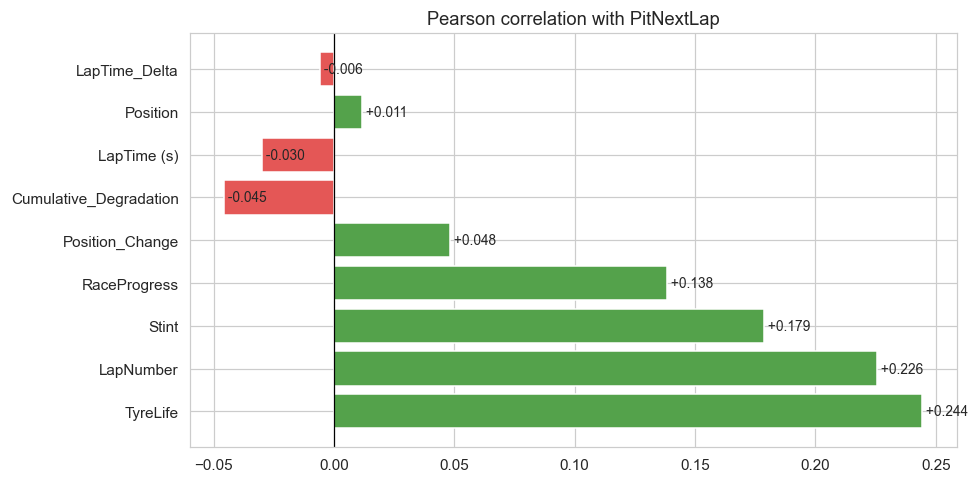

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#54A24B' if v > 0 else '#E45756' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title('Pearson correlation with PitNextLap')
ax.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(corr.values):
    ax.text(v, i, f' {v:+.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figures/06_feature_correlations.png'), bbox_inches='tight')
plt.show()

**Findings**
- `TyreLife` (+0.244) > `LapNumber` (+0.226) > `Stint` (+0.179) > `RaceProgress` (+0.139) — all the late-stint / late-race signals are positively correlated.
- `Cumulative_Degradation` is *negatively* correlated, which looks counter-intuitive but reflects how the column is constructed (it's a delta vs a reference, not raw wear).

## 9. Feature engineering

All features computed within the group key `(Year, Race, Driver, Stint)` so nothing leaks across pit stops or races. `shift(1)` is applied before any rolling so the current lap isn't part of its own feature.

**19 new features:**
- Lag features: `LapTime_lag{1,2,3}`, `LapTime_Delta_lag{1,2,3}`, `Position_lag{1,2,3}`
- Rolling LapTime: `LapTime_roll{3,5}_mean/std`, `LapTimeDelta_roll{3,5}_mean`
- TyreLife bucket (9 categorical buckets)
- Race phase: `IsEarlyRace`, `IsLateRace`
- Pace degradation: `LapTime_vs_StintMin`

In [15]:
def add_features(df):
    df = df.sort_values(['Year','Race','Driver','Stint','LapNumber']).reset_index(drop=True)
    key = ['Year','Race','Driver','Stint']
    g = df.groupby(key, sort=False)

    # lag features
    for lag in (1, 2, 3):
        df[f'LapTime_lag{lag}']       = g['LapTime (s)'].shift(lag)
        df[f'LapTime_Delta_lag{lag}'] = g['LapTime_Delta'].shift(lag)
        df[f'Position_lag{lag}']      = g['Position'].shift(lag)

    # rolling over PAST laps only: shift(1) inside the group, then roll
    for w in (3, 5):
        df[f'LapTime_roll{w}_mean'] = g['LapTime (s)'].transform(
            lambda s: s.shift(1).rolling(w, min_periods=1).mean())
        df[f'LapTime_roll{w}_std'] = g['LapTime (s)'].transform(
            lambda s: s.shift(1).rolling(w, min_periods=2).std())
        df[f'LapTimeDelta_roll{w}_mean'] = g['LapTime_Delta'].transform(
            lambda s: s.shift(1).rolling(w, min_periods=1).mean())

    # bucket
    df['TyreLife_bucket'] = pd.cut(df['TyreLife'],
        bins=[-0.1, 5, 10, 15, 20, 25, 30, 40, 60, 200],
        labels=['0_5','6_10','11_15','16_20','21_25','26_30','31_40','41_60','60plus']).astype(str)

    # race phase
    df['IsEarlyRace'] = (df['RaceProgress'] < 0.25).astype(int)
    df['IsLateRace']  = (df['RaceProgress'] > 0.70).astype(int)

    # pace vs best lap SO FAR in the stint (expanding min, no future laps)
    df['StintMin_sofar']      = g['LapTime (s)'].cummin()
    df['LapTime_vs_StintMin'] = df['LapTime (s)'] - df['StintMin_sofar']
    return df

train_fe = add_features(train)
test_fe  = add_features(test)
print('train_fe:', train_fe.shape)
print('test_fe :', test_fe.shape)
new_cols = sorted(set(train_fe.columns) - set(train.columns))
print(f'\nAdded {len(new_cols)} new features:')
for c in new_cols: print('  -', c)

train_fe: (346246, 36)
test_fe : (92894, 36)

Added 20 new features:
  - IsEarlyRace
  - IsLateRace
  - LapTimeDelta_roll3_mean
  - LapTimeDelta_roll5_mean
  - LapTime_Delta_lag1
  - LapTime_Delta_lag2
  - LapTime_Delta_lag3
  - LapTime_lag1
  - LapTime_lag2
  - LapTime_lag3
  - LapTime_roll3_mean
  - LapTime_roll3_std
  - LapTime_roll5_mean
  - LapTime_roll5_std
  - LapTime_vs_StintMin
  - Position_lag1
  - Position_lag2
  - Position_lag3
  - StintMin_sofar
  - TyreLife_bucket


In [16]:
# Sanity check: NaN counts in new lag features (early-stint rows naturally have NaN)
train_fe[new_cols].isna().sum().sort_values(ascending=False)

LapTime_Delta_lag3         205128
LapTime_lag3               205128
Position_lag3              205128
Position_lag2              155644
LapTime_Delta_lag2         155644
LapTime_lag2               155644
LapTime_roll3_std          155644
LapTime_roll5_std          155644
LapTime_roll3_mean          90644
LapTimeDelta_roll3_mean     90644
LapTimeDelta_roll5_mean     90644
LapTime_Delta_lag1          90644
LapTime_lag1                90644
LapTime_roll5_mean          90644
Position_lag1               90644
StintMin_sofar                  0
IsEarlyRace                     0
LapTime_vs_StintMin             0
IsLateRace                      0
TyreLife_bucket                 0
dtype: int64

In [17]:
# Quick correlation check: do the new features add signal?
candidate = ['TyreLife','LapNumber','LapTime_lag1','LapTime_roll3_mean','LapTime_roll5_std',
             'LapTime_vs_StintMin','IsLateRace']
train_fe[candidate + ['PitNextLap']].corr()['PitNextLap'].drop('PitNextLap').round(4)

TyreLife               0.2443
LapNumber              0.2255
LapTime_lag1          -0.0321
LapTime_roll3_mean    -0.0337
LapTime_roll5_std     -0.0129
LapTime_vs_StintMin    0.0128
IsLateRace            -0.0372
Name: PitNextLap, dtype: float64

## 10. Metric definition + baselines

**Primary metric: F1-macro** — treats both classes equally, immune to class imbalance.  
**Secondary metric: AUC-ROC** — threshold-free, used for tracking model degradation in monitoring.

We **do not** use Accuracy because the trivial "always predict 0" classifier scores 0.72 on test while catching zero pit stops.

In [18]:
def confusion(y_true, y_pred):
    tp = int(((y_pred==1) & (y_true==1)).sum())
    tn = int(((y_pred==0) & (y_true==0)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    return tp, tn, fp, fn

def metrics_from(y_true, y_pred):
    tp, tn, fp, fn = confusion(y_true, y_pred)
    n = tp+tn+fp+fn
    acc = (tp+tn)/n if n else 0
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec  = tp/(tp+fn) if (tp+fn) else 0
    f1_pos = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    prec_n = tn/(tn+fn) if (tn+fn) else 0
    rec_n  = tn/(tn+fp) if (tn+fp) else 0
    f1_neg = 2*prec_n*rec_n/(prec_n+rec_n) if (prec_n+rec_n) else 0
    return dict(accuracy=acc, precision=prec, recall=rec,
                f1_pos=f1_pos, f1_macro=(f1_pos+f1_neg)/2)

def auc_roc(y_true, score):
    y_true = np.asarray(y_true); score = np.asarray(score, dtype=float)
    order = np.argsort(score, kind='mergesort')
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(score)+1)
    s = score[order]
    i = 0
    while i < len(s):
        j = i
        while j+1 < len(s) and s[j+1] == s[i]:
            j += 1
        if j > i:
            ranks[order[i:j+1]] = (ranks[order[i]] + ranks[order[j]]) / 2.0
        i = j + 1
    n_pos = int((y_true==1).sum()); n_neg = int((y_true==0).sum())
    return float((ranks[y_true==1].sum() - n_pos*(n_pos+1)/2) / (n_pos*n_neg))

In [19]:
y = test['PitNextLap'].astype(int).values

# Baseline 1: always predict 0
m0 = metrics_from(y, np.zeros_like(y)); m0['auc'] = 0.5

# Baseline 2: simple heuristic (predict 1 if TyreLife >= 25)
score = test['TyreLife'].values.astype(float)
m1 = metrics_from(y, (score >= 25).astype(int)); m1['auc'] = auc_roc(y, score)

baseline_df = pd.DataFrame({'Dummy (predict 0)': m0, 'Rule TyreLife>=25': m1}).T
baseline_df.round(4)

,accuracy,precision,recall,f1_pos,f1_macro,auc
Dummy (predict 0),0.7156,0.0000,0.0000,0.0000,0.4171,0.5000
Rule TyreLife>=25,0.7336,0.5578,0.3059,0.3951,0.6122,0.7394


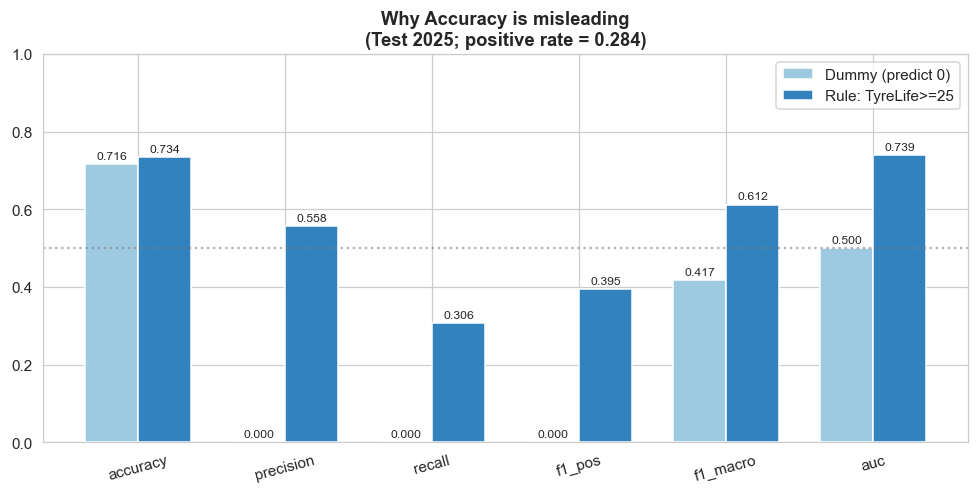

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.6))
mets = ['accuracy','precision','recall','f1_pos','f1_macro','auc']
x = np.arange(len(mets)); w = 0.36
ax.bar(x-w/2, [m0[k] for k in mets], width=w, label='Dummy (predict 0)', color='#9ecae1')
ax.bar(x+w/2, [m1[k] for k in mets], width=w, label='Rule: TyreLife>=25', color='#3182bd')
ax.set_xticks(x); ax.set_xticklabels(mets, rotation=15)
ax.set_ylim(0, 1)
ax.set_title(f'Why Accuracy is misleading\n(Test 2025; positive rate = {y.mean():.3f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6)
for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figures/05_metric_comparison.png'), bbox_inches='tight')
plt.show()

**Take-aways for the team**
- The dummy classifier hits 71.6 % accuracy but catches **zero** pit stops — useless for a strategist. F1-macro (0.42) and AUC (0.50) correctly flag it.
- A trivial "TyreLife ≥ 25" rule already reaches F1-macro 0.61 and AUC 0.74 — **this is the floor Member B must beat with AutoML.**
- Member C should expose raw probabilities, not just labels, so the strategy team can pick their own operating threshold.

## 11. Save artifacts

In [21]:
# Raw splits
train.to_csv(os.path.join(OUT_DIR, 'data/train_raw.csv'), index=False)
test.to_csv (os.path.join(OUT_DIR, 'data/test_raw.csv'),  index=False)
# Feature-engineered
train_fe.to_csv(os.path.join(OUT_DIR, 'data/train_fe.csv'), index=False)
test_fe.to_csv (os.path.join(OUT_DIR, 'data/test_fe.csv'),  index=False)

# Baseline metrics report
with open(os.path.join(OUT_DIR, 'reports/baseline_metrics.json'), 'w') as f:
    json.dump({'dummy': m0, 'tyrelife_rule_ge25': m1,
               'test_size': int(len(y)), 'test_pos_rate': float(y.mean())},
              f, indent=2)

with open(os.path.join(OUT_DIR, 'reports/baseline_metrics.txt'), 'w') as f:
    f.write('PART A — BASELINE METRICS REFERENCE\n')
    f.write('='*70 + '\n\n')
    f.write(f'Train (2022-2024): n={len(train):,}  positive_rate={train["PitNextLap"].mean():.4f}\n')
    f.write(f'Test  (2025):      n={len(test):,}  positive_rate={test["PitNextLap"].mean():.4f}\n\n')
    f.write('--- Dummy (predict 0) ---\n')
    for k, v in m0.items(): f.write(f'  {k:<10} = {v:.4f}\n')
    f.write('\n--- Rule TyreLife>=25 ---\n')
    for k, v in m1.items(): f.write(f'  {k:<10} = {v:.4f}\n')
    f.write('\nMember B target: F1-macro > 0.61 and AUC > 0.74\n')

print('All files written under:', OUT_DIR)
for root, _, files in os.walk(OUT_DIR):
    for fn in sorted(files):
        print(' ', os.path.relpath(os.path.join(root, fn), OUT_DIR))

All files written under: ./EDA_output
  figures/01_class_distribution.png
  figures/02_compound_analysis.png
  figures/03_tyrelife_vs_pitnextlap.png
  figures/04_year_drift.png
  figures/05_metric_comparison.png
  figures/06_feature_correlations.png
  data/test_fe.csv
  data/test_raw.csv
  data/train_fe.csv
  data/train_raw.csv
  reports/baseline_metrics.json
  reports/baseline_metrics.txt


## 12. Summary for the team

### What this EDA produced
| Artifact | Use |
|---|---|
| `data/train_fe.csv`, `data/test_fe.csv` |AutoML, inference |
| 6 figures in `figures/` | EDA & Metric |
| `reports/baseline_metrics.json` | Floor for AutoML to beat |

### Three findings to highlight
1. **2023 has anomalously sparse pit-stop labels** (0.96 % vs 27–30 % for other years). We should run an ablation with/without 2023 and should pre-empt this in the drift dashboard narrative.
2. **Test (2025) pit-rate (28.4 %) is ≈ 60 % higher than train (17.6 %)** — partly explained by #1; expect calibration to drift slightly.
3. **TyreLife + Compound** are the dominant predictors. Next monitoring should prioritise drift on those two features, with `LapTime_roll*_std` as a pace-volatility canary.

### Baseline to beat
- F1-macro ≥ **0.61** (TyreLife≥25 rule)  
- AUC-ROC  ≥ **0.74** (TyreLife as score)  
- Realistic AutoML target with engineered features: F1-macro ≥ 0.70, AUC ≥ 0.85.